In [1]:
import pandas as pd
import numpy as np

# Homework 1 - Benjamin Carrera 

## Q1: Pandas version

In [2]:
pd.__version__

'2.3.1'

## Q2: Records count

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [4]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [5]:
print(f'The dataset has {df.shape[0]} records.')

The dataset has 10000 records.


## Q3: Fuel types

In [6]:
fuel_types = df.fuel_type.unique()
print(f'The number of different fuel types is {fuel_types.shape[0]}.')

The number of different fuel types is 3.


## Q4: Missing values

In [7]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

There are 2 columns with missing values.

## Q5: Max Fuel efficiency

In [8]:
df[df.origin == 'Asia'].max()

model_year                         2024
origin                             Asia
fuel_type                        Hybrid
drivetrain             Rear-wheel drive
num_doors                             5
engine_displacement                3020
num_cylinders                         8
horsepower                        334.0
vehicle_weight                     5280
acceleration                       23.8
fuel_efficiency_mpg                41.2
dtype: object

The maximum fuel efficiency of cars from Asia is 41.2.

## Q6: Max value of horsepower

In [9]:
horsepower = df.horsepower
#1
hp_median = horsepower.median()
print('1. The median of the horse power column is:', hp_median)
#2
hp_mode = horsepower.mode()[0]
print('2. The most frequent value (mode) of the horse power column is:',hp_mode)

1. The median of the horse power column is: 254.0
2. The most frequent value (mode) of the horse power column is: 252.0


<Axes: >

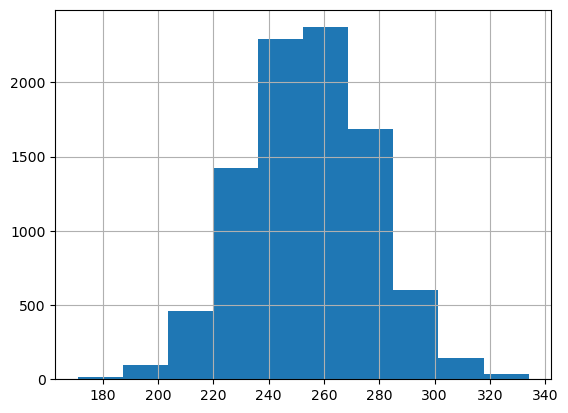

In [10]:
horsepower.hist()

In [11]:
#3
hp_filled = horsepower.fillna(hp_mode)
#4
hp_median_filled = hp_filled.median()
print('The median of the horse power column (with NaN values replaced by the mode) is:',hp_median_filled)

The median of the horse power column (with NaN values replaced by the mode) is: 252.0


<Axes: >

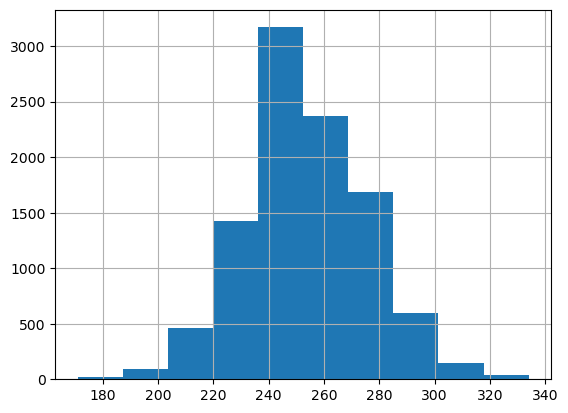

In [12]:
hp_filled.hist()

So, the median decresed by 2 units, and now its the same as the mode of the column.

## Q7: Sum of weigths

In [13]:
#1
df_7 = df[df.origin == 'Asia']
#2
df_7 = df_7[['vehicle_weight','model_year']]
#3
first_seven = df_7.iloc[0:7]
first_seven

,vehicle_weight,model_year
2,4240,1996
6,4310,1992
8,4230,1997
10,4420,1978
15,3950,2007
16,4750,2021
22,4450,2019


In [16]:
#4
X = first_seven.values
#5
XT = X.T
XTX = XT.dot(X)
XTX

array([[131950500,  60750580],
       [ 60750580,  28041424]])

In [17]:
#6
XTX_inv = np.linalg.inv(XTX)
XTX_inv 

array([[ 2.96830537e-06, -6.43071025e-06],
       [-6.43071025e-06,  1.39675281e-05]])

In [21]:
#7
y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])
XTX_1_XT = XTX_inv.dot(X.T)
XTX_1_XT

array([[-2.50082897e-04, -1.65786806e-05, -2.86196661e-04,
         3.99964853e-04, -1.18162927e-03,  1.10298508e-03,
         2.25354894e-04],
       [ 6.12974614e-04,  1.06954785e-04,  6.91249245e-04,
        -7.95968736e-04,  2.63152339e-03, -2.31749941e-03,
        -4.16221392e-04]])

In [24]:
#8
w = XTX_1_XT.dot(y)
w

array([0.13644777, 0.2327492 ])

In [32]:
#9
weights_sum = np.sum(w)
print(f'The sum of all elements of the vector w is {weights_sum.round(3)}.')

The sum of all elements of the vector w is 0.369.
